In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("Visadataset.csv")
df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [4]:
wage_data = df["prevailing_wage"]
wage_data 

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

#### Percentile or Quartile : 

In [6]:
p_25 = np.percentile(wage_data,25)
p_25

34015.479999999996

In [10]:
np.sum(wage_data<p_25)    # This gives total number of records which has less then p_25 value.

6370

In [9]:
p_50 = wage_data.median()   
p_50

70308.20999999999

In [11]:
p_50 = np.percentile(wage_data,50)
p_50

70308.20999999999

In [14]:
np.sum(wage_data<p_50)

12740

In [13]:
p_75 = np.percentile(wage_data,75)
p_75

107735.51250000001

In [15]:
np.sum(wage_data<p_75)

19110

In [20]:
mean = wage_data.mean()

In [21]:
std = wage_data.std()

#### Checking Emperical Rule : 
        - check the 68%-95%-99.70% Rule applicable on data or not.

#### calculating 68% :

In [38]:
lb = mean-std

In [39]:
ub = mean+std

In [40]:
np.sum((wage_data>lb)&(wage_data<ub))

17171

In [42]:
per = (68/100)*25479
per

17325.72

In [43]:
(17171/25479)*100

67.392754817693

In [44]:
per==np.sum((wage_data>lb)&(wage_data<ub))   # So 68% data is not exactly in between mu-sigma to mu+sigma, so it is not perfect normal ditribution.

False

#### calculating 95% :

In [45]:
lb = mean-2*std
ub = mean+2*std
value = np.sum((wage_data>lb)&(wage_data<ub))
per = (95/100)*25479
value==per   # So 95% data is not exactly in between mu-2*sigma to mu+2*sigma, so it is not perfect normal ditribution.

False

(array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
          21.]),
 array([2.13670000e+00, 3.19229500e+04, 6.38437634e+04, 9.57645767e+04,
        1.27685390e+05, 1.59606203e+05, 1.91527017e+05, 2.23447830e+05,
        2.55368643e+05, 2.87289457e+05, 3.19210270e+05]),
 <BarContainer object of 10 artists>)

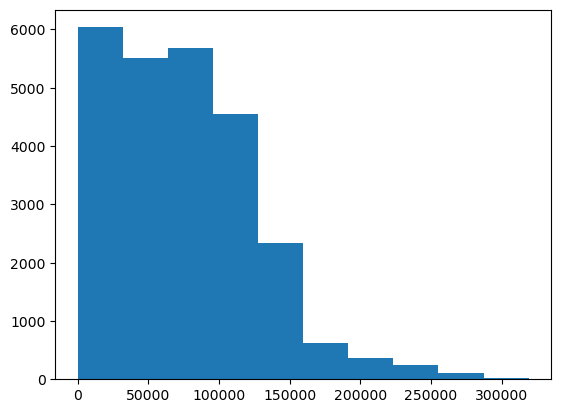

In [37]:
plt.hist(wage_data)

In [22]:
wage_data.skew()

0.7557760603032042

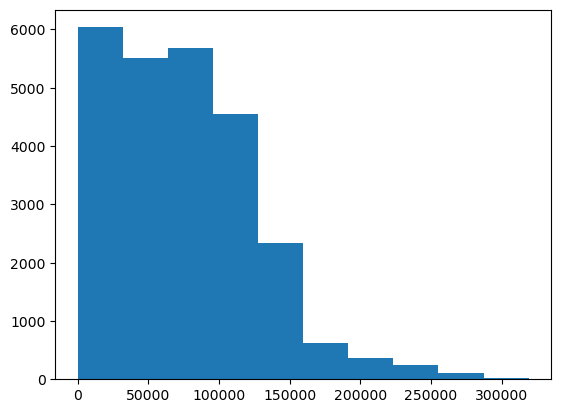

In [46]:
count,intervals,n=plt.hist(wage_data)

In [47]:
count

array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
         21.])

In [48]:
intervals

array([2.13670000e+00, 3.19229500e+04, 6.38437634e+04, 9.57645767e+04,
       1.27685390e+05, 1.59606203e+05, 1.91527017e+05, 2.23447830e+05,
       2.55368643e+05, 2.87289457e+05, 3.19210270e+05])

In [53]:
n

<BarContainer object of 10 artists>

In [56]:
# 2.13670000e+00 to 3.19229500e+04

value = np.sum((wage_data>2.13670000e+00)&(wage_data<3.19229500e+04))
value

6037

In [58]:
count[0]

6038.0

In [59]:
value==count[0]   # small difference is there but it is negligible. so in first interval 6038 records(values from wage_data) are there.

False

In [60]:
# So check above condition for every interval i.e for total 10 intervals.

#### Outliers : 
 - (Q1-1.5IQR) or (Q3+1.5IQR)

{'whiskers': [<matplotlib.lines.Line2D at 0x1a972552b10>,
 'caps': [<matplotlib.lines.Line2D at 0x1a972b7a390>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a9724e5550>],
 'medians': [<matplotlib.lines.Line2D at 0x1a972b6b910>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a972552d90>],
 'means': []}

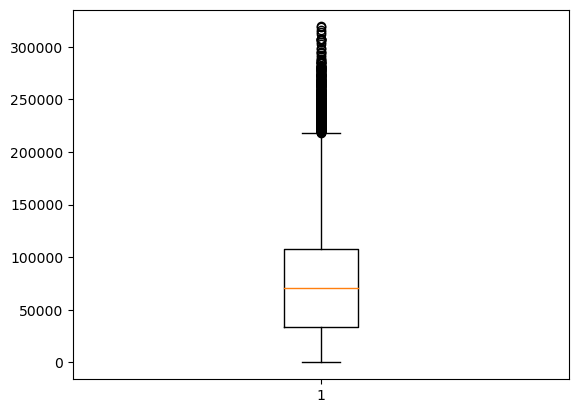

In [64]:
plt.boxplot(wage_data)

In [72]:
q3 = np.percentile(wage_data,75)
q3

107735.51250000001

In [71]:
q1 = np.percentile(wage_data,25)
q1

34015.479999999996

In [73]:
IQR = q3-q1
IQR

73720.03250000002

In [94]:
ul = q3 + 1.5*IQR
ul

218315.56125000003

In [95]:
ul = np.percentile(wage_data,75) + 1.5*((np.percentile(wage_data,75)-np.percentile(wage_data,25)))
ul

218315.56125000003

In [83]:
np.sum(wage_data>ul)

427

In [84]:
ll = q1 - 1.5*IQR

In [87]:
np.sum(wage_data<ll)

0

In [88]:
np.sum(wage_data>ul) | np.sum(wage_data<ll)

427

In [92]:
outliers = []

for i in wage_data :
    if i > ul :
       outliers.append(i)
    
    
outliers

[220081.73,
 225569.73,
 247393.01,
 269321.68,
 219529.62,
 232227.33,
 238691.32,
 220448.17,
 230750.48,
 235339.91,
 232680.65,
 256261.78,
 262189.0,
 250510.67,
 218554.78,
 256205.38,
 221944.22,
 229950.7,
 222628.84,
 229819.69,
 233641.72,
 274019.43,
 218982.83,
 230984.28,
 223128.23,
 246705.0,
 240266.34,
 226090.72,
 231949.27,
 254604.08,
 288318.91,
 244457.48,
 242146.48,
 247545.23,
 234139.17,
 231834.72,
 222730.57,
 239773.63,
 220553.95,
 237539.32,
 266440.49,
 277281.01,
 275627.59,
 249291.12,
 292106.59,
 234012.11,
 247009.24,
 267726.09,
 222098.09,
 280661.13,
 277984.52,
 262852.71,
 263877.21,
 230916.64,
 264760.64,
 267868.56,
 222221.67,
 242406.32,
 276894.08,
 281832.93,
 221033.57,
 258292.84,
 223492.85,
 245418.67,
 250289.08,
 271344.69,
 252825.11,
 230843.7,
 253668.86,
 245819.17,
 239465.3,
 236316.36,
 225268.13,
 228941.33,
 306021.96,
 228074.25,
 270799.93,
 221982.69,
 256903.7,
 242813.07,
 253111.05,
 268440.33,
 225681.78,
 233150.41